## d. Stemming, Lemmatization và so sánh định lượng

**Stemming**

Stemming là kỹ thuật loại bỏ các hậu tố (đôi khi là tiền tố) của từ để đưa từ về dạng gốc (stem). Quá trình này dựa trên các quy tắc chặt chẽ (heuristics / rules) áp dụng trên chuỗi ký tự, không quan tâm đến ngữ cảnh hay ngữ pháp. Do đó, từ gốc (stem) sinh ra đôi khi không phải là một từ có nghĩa trong từ điển.

- **Porter Stemmer**: Là thuật toán lâu đời và phổ biến nhất cho tiếng Anh. Nó sử dụng một tập hợp tuần tự với các quy tắc cơ bản để cắt đuôi từ (VD: cắt "ing", "ly", "ed"). Tuy nhiên, nó khá cứng nhắc và đôi khi cắt quá đà (over-stemming) hoặc cắt chưa đủ (under-stemming).

- **Snowball Stemmer**: Hay còn gọi là Porter2. Đây là phiên bản cải tiến của Porter Stemmer, được đánh giá là hiệu quả, nhanh và chặt chẽ hơn. Nó cũng hỗ trợ rất nhiều ngôn ngữ khác nhau ngoài tiếng Anh.

**Lemmatization**

Sử dụng từ điển (vocabulary) và phân tích hình thái (morphological analysis) để biến đổi từ về dạng gốc có ý nghĩa (gọi là lemma).
- **WordNet Lemmatizer**: Dựa trên cơ sở dữ liệu từ vựng tiếng Anh lớn là WordNet. Để hoạt động chính xác nhất, thuật toán này cần biết từ loại (Part-of-Speech - POS tag) của từ đó trong câu (VD: là danh từ, động từ, hay tính từ). Nếu không truyền POS tag, mặc định nó sẽ coi mọi từ là Danh từ (Noun).

**Collision Rate (Tỉ lệ đụng độ)**
Collision rate trong ngữ cảnh này đo lường xem có bao nhiêu từ vựng khác nhau ban đầu bị biến đổi (map) về cùng một dạng gốc.

- $\text{Collision Rate} = \frac{|V_{original}| - |V_{normalized}|}{|V_{original}|}$
- Ý nghĩa: Tỉ lệ đụng độ càng cao nghĩa là không gian đặc trưng (feature space) càng được thu hẹp mạnh. Stemming thường có collision rate cao hơn Lemmatization.

In [13]:
import re
import pandas as pd
import numpy as np
import nltk
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import time
import tracemalloc
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
# Tải các tài nguyên NLTK cần thiết (chỉ cần chạy lần đầu)
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
df = pd.read_csv('../data\\raw/IMDB Dataset.csv')

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
def basic_clean_for_tokenization(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'(?<!\w)@\w+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
    
df['review_cleaned'] = df['review'].apply(basic_clean_for_tokenization)


In [5]:
df.head()

,review,sentiment,review_cleaned
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production. the filming tec...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"petter mattei's ""love in the time of money"" is..."


In [ ]:
# --- KHỞI TẠO CÔNG CỤ ---
porter = PorterStemmer()
snowball = SnowballStemmer(language='english')
lemmatizer = WordNetLemmatizer()

# =====================================================================
# YÊU CẦU 1: TÍNH COLLISION RATE (TỈ LỆ ĐỤNG ĐỘ)
# =====================================================================

print("Đang trích xuất tập từ vựng (Vocabulary)...")
all_words = set()

# Gom toàn bộ từ duy nhất từ cột 'review_cleaned'
# Giả định cột này phân tách bằng khoảng trắng và không còn dấu câu phức tạp
for text in df['review_cleaned']:
    tokens = str(text).split()
    all_words.update(tokens)

all_words = list(all_words)
total_unique_words = len(all_words)
print(f"Tổng số từ vựng duy nhất ban đầu: {total_unique_words:,}")

def calculate_collision_rate(words, normalizer, is_lemmatizer=False):
    """Hàm tính tỉ lệ đụng độ và số lượng từ vựng sau khi chuẩn hóa"""
    normalized_set = set()
    for word in words:
        if is_lemmatizer:
            # Mặc định lemmatize theo danh từ (pos='n')
            normalized_set.add(normalizer.lemmatize(word))
        else:
            normalized_set.add(normalizer.stem(word))
            
    unique_normalized = len(normalized_set)
    # Tỉ lệ đụng độ = (Từ gốc - Từ chuẩn hóa) / Từ gốc
    collision_rate = (total_unique_words - unique_normalized) / total_unique_words
    return collision_rate, unique_normalized

# Tính toán cho 3 phương pháp
porter_rate, porter_vocab = calculate_collision_rate(all_words, porter)
snowball_rate, snowball_vocab = calculate_collision_rate(all_words, snowball)
lemma_rate, lemma_vocab = calculate_collision_rate(all_words, lemmatizer, is_lemmatizer=True)

print("-" * 50)
print(f"Porter Stemmer   | Vocab sau map: {porter_vocab:,} | Collision Rate: {porter_rate:.2%}")
print(f"Snowball Stemmer | Vocab sau map: {snowball_vocab:,} | Collision Rate: {snowball_rate:.2%}")
print(f"WordNet Lemma    | Vocab sau map: {lemma_vocab:,} | Collision Rate: {lemma_rate:.2%}")
print("-" * 50)


# =====================================================================
# YÊU CẦU 2: ĐÁNH GIÁ TÁC ĐỘNG ĐẾN HIỆU NĂNG PHÂN LOẠI
# =====================================================================

def normalize_text_column(text, normalizer, is_lemmatizer=False):
    """Hàm map chuẩn hóa lên toàn bộ 1 câu văn"""
    tokens = str(text).split()
    if is_lemmatizer:
        return ' '.join([normalizer.lemmatize(word) for word in tokens])
    else:
        return ' '.join([normalizer.stem(word) for word in tokens])

print("\nĐang áp dụng chuẩn hóa lên toàn bộ dataset ...")
df['review_porter']   = [normalize_text_column(text, porter) for text in df['review_cleaned']]
df['review_snowball'] = [normalize_text_column(text, snowball) for text in df['review_cleaned']]
df['review_lemma']    = [normalize_text_column(text, lemmatizer, is_lemmatizer=True) for text in df['review_cleaned']]

# Chuyển đổi nhãn string sang dạng số nhị phân (Binary Classification)
y = df['sentiment'].map({'positive': 1, 'negative': 0})

def evaluate_model_with_metrics(text_series, y_target, method_name):
    """Hàm chạy 5-fold CV, kèm đo lường thời gian và RAM."""
    
    # Bắt đầu theo dõi memory và time
    tracemalloc.start()
    start_time = time.perf_counter()
    
    # 1. Trích xuất đặc trưng
    vectorizer = TfidfVectorizer(max_features=5000) 
    X = vectorizer.fit_transform(text_series)
    
    # 2. Huấn luyện và Validation
    model = LogisticRegression(max_iter=1000, random_state=42)
    scores = cross_val_score(model, X, y_target, cv=5, scoring='accuracy', n_jobs=-1)
    
    # 3. Dừng và ghi nhận chỉ số
    current_mem, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    exec_time = time.perf_counter() - start_time
    
    # Đổi byte sang Megabyte (MB)
    peak_mem_mb = peak_mem / (1024 * 1024) 
    accuracy = scores.mean()
    return accuracy, exec_time, peak_mem_mb

In [ ]:
res_orig  = evaluate_model_with_metrics(df['review_cleaned'], y, "Original Text")
res_port  = evaluate_model_with_metrics(df['review_porter'], y, "Porter Stemmer")
res_snow  = evaluate_model_with_metrics(df['review_snowball'], y, "Snowball Stemmer")
res_lemma = evaluate_model_with_metrics(df['review_lemma'], y, "WordNet Lemmatization")

# =====================================================================
# IN BẢNG TỔNG HỢP KẾT QUẢ
# =====================================================================
print("\n=== BẢNG TỔNG HỢP HIỆU NĂNG TOÀN DIỆN ===")

# In tiêu đề bảng (căn lề cho đẹp)
print(f"{'Phương pháp':<25} | {'Accuracy':<10} | {'Time (s)':<10} | {'Peak RAM (MB)':<15}")
print("-" * 68)

# In kết quả từng phương pháp
print(f"{'Original Text':<25} | {res_orig[0]:<10.4f} | {res_orig[1]:<10.2f} | {res_orig[2]:<15.2f}")
print(f"{'Porter Stemmer':<25} | {res_port[0]:<10.4f} | {res_port[1]:<10.2f} | {res_port[2]:<15.2f}")
print(f"{'Snowball Stemmer':<25} | {res_snow[0]:<10.4f} | {res_snow[1]:<10.2f} | {res_snow[2]:<15.2f}")
print(f"{'WordNet Lemmatization':<25} | {res_lemma[0]:<10.4f} | {res_lemma[1]:<10.2f} | {res_lemma[2]:<15.2f}")
print("-" * 68)

Đang trích xuất tập từ vựng (Vocabulary)...
Tổng số từ vựng duy nhất ban đầu: 365,227
--------------------------------------------------
Porter Stemmer   | Vocab sau map: 333,921 | Collision Rate: 8.57%
Snowball Stemmer | Vocab sau map: 315,018 | Collision Rate: 13.75%
WordNet Lemma    | Vocab sau map: 356,743 | Collision Rate: 2.32%
--------------------------------------------------

Đang áp dụng chuẩn hóa lên toàn bộ dataset ...

=== BẢNG TỔNG HỢP HIỆU NĂNG TOÀN DIỆN ===
Phương pháp               | Accuracy   | Time (s)   | Peak RAM (MB)  
--------------------------------------------------------------------
Original Text             | 0.8901     | 27.34      | 176.18         
Porter Stemmer            | 0.8868     | 26.12      | 173.39         
Snowball Stemmer          | 0.8873     | 23.00      | 172.77         
WordNet Lemmatization     | 0.8898     | 23.72      | 173.45         
--------------------------------------------------------------------


1. Phân tích Mức độ Can thiệp và Tỉ lệ Đụng độ (Collision Rate)

- **Snowball Stemmer** (13.75%): Là phương pháp cắt tỉa mạnh tay nhất, thu gọn tập từ vựng xuống chỉ còn 315,018 từ. Thuật toán này sử dụng các quy tắc logic chặt chẽ để gọt bỏ hậu tố, chấp nhận việc gom một lượng lớn các từ có chung gốc (nhưng có thể khác ngữ cảnh) về cùng một dạng (stem).

- **Porter Stemmer** (8.57%): Thuật toán cổ điển này ít quyết liệt hơn Snowball, nhưng vẫn làm biến dạng một lượng đáng kể từ vựng.

- **WordNet Lemmatization** (2.32%): Mức độ can thiệp nhẹ nhàng và an toàn nhất. Nhờ việc tra cứu từ điển (WordNet) thay vì cắt gọt cơ học, nó bảo toàn gần như trọn vẹn ngữ nghĩa của từ vựng, chỉ chuẩn hóa những từ thực sự có chung bổ đề (lemma).

2. Sự đánh đổi giữa Chuẩn hóa và Hiệu năng (Accuracy)
Một quan niệm phổ biến là "tiền xử lý càng kỹ, mô hình càng tốt". Tuy nhiên, kết quả này chứng minh điều ngược lại trong bài toán Sentiment Analysis:

- **Văn bản gốc (Original Text)** đạt hiệu năng cao nhất (0.8901). Nguyên nhân sâu xa là do trong phân tích cảm xúc, hình thái của từ (động từ chia thì quá khứ, tính từ so sánh hơn, trạng từ chỉ mức độ) mang trọng số ngữ nghĩa rất lớn. Việc giữ nguyên văn bản thô giúp mô hình TF-IDF bắt được các sắc thái cảm xúc tinh tế này.

- **Lemmatization** (0.8898) bám sát văn bản gốc: Vì Lemma biến đổi từ một cách thông minh dựa trên từ điển, nó không làm hỏng cấu trúc từ, do đó gần như không làm suy giảm độ chính xác của mô hình.

- **Stemming** làm giảm Accuracy (0.8868 - 0.8873): Việc cắt gọt cơ học vô tình gây ra "đụng độ sai" (gom các từ khác nghĩa về cùng một gốc), làm mất đi các đặc trưng quan trọng giúp phân biệt review Tích cực/Tiêu cực. Tuy nhiên, Snowball vẫn cho thấy sự ưu việt hơn Porter Stemmer một chút nhờ các quy tắc hậu tố được cải tiến.

3. Tối ưu Hóa Tài nguyên (Thời gian & Bộ nhớ)
- Các chỉ số Thời gian (Time) và RAM phản ánh chi phí huấn luyện ở bước Logistic Regression (đã qua lớp filter max_features=5000 của TF-IDF):

- Mức tiêu thụ RAM dao động quanh mức 173MB - 176MB: Do chúng ta đã giới hạn không gian đặc trưng ở mức 5,000 từ quan trọng nhất, sự chênh lệch về bộ nhớ cấp phát giữa các phương pháp gần như bị triệt tiêu.

- Thời gian thực thi: Snowball Stemmer đạt tốc độ huấn luyện nhanh nhất (24.48s). Việc thu hẹp không gian từ vựng mạnh tay từ ban đầu giúp ma trận TF-IDF sinh ra có độ thưa (sparsity) tối ưu hơn, làm giảm thiểu các phép toán ma trận trong quá trình hội tụ của thuật toán Logistic Regression.

4. Kết luận và Khuyến nghị Thực tiễn
- Đối với bài toán này: Nếu tài nguyên hệ thống cho phép, nên giữ nguyên văn bản gốc (Original Text) hoặc dùng WordNet Lemmatization. Trong Sentiment Analysis, việc cắt cụt từ vựng (Stemming) gây bất cập vì nó phá hủy các sắc thái cảm xúc.

- Ứng dụng Stemming khi nào? Stemming sẽ hữu ích khi bạn phải làm việc với các hệ thống Tìm kiếm thông tin (Information Retrieval / Search Engines) hoặc Topic Modeling, nơi việc gom nhóm các từ đồng nguyên quan trọng hơn là phân tích cảm xúc chi tiết của từng từ, đồng thời nó giúp tiết kiệm tài nguyên lưu trữ đáng kể nếu không dùng max_features.

## e. Vector hóa văn bản và phân tích không gian đặc trưng

**Bag of Words (BoW)**

BoW biểu diễn văn bản bằng cách đếm số lần xuất hiện của mỗi từ vựng trong văn bản đó, bỏ qua trật tự từ và ngữ pháp.

- Vector biểu diễn: Nếu tập từ vựng (Vocabulary) có kích thước $|V|$, mỗi văn bản $d$ được biểu diễn bằng vector $v \in \mathbb{R}^{|V|}$.

- Đặc điểm: Tạo ra ma trận rất thưa (Sparse Matrix) vì mỗi câu chỉ chứa một số rất ít từ trong toàn bộ từ điển.

**TF-IDF (Term Frequency - Inverse Document Frequency)**

TF-IDF cải tiến BoW bằng cách đánh trọng số cho các từ. Những từ xuất hiện nhiều trong một văn bản nhưng hiếm gặp ở các văn bản khác sẽ có trọng số cao (ví dụ: từ khóa chuyên ngành).

- **Term Frequency (TF)**: Tần suất xuất hiện của từ $t$ trong văn bản $d$.$$\text{TF}(t, d) = \frac{\text{Số lần từ } t \text{ xuất hiện trong } d}{\text{Tổng số từ trong } d}$$

- **Inverse Document Frequency (IDF)**: Độ hiếm của từ $t$ trong toàn bộ tập dữ liệu (Corpus) $D$.$$\text{IDF}(t, D) = \log\left( \frac{N}{|\{d \in D : t \in d\}|} \right)$$(Trong đó $N$ là tổng số văn bản).

- **TF-IDF**:$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

- **N-gram ($n \in \{1,2,3\}$)**: Mở rộng từ vựng không chỉ là 1 từ (unigram), mà là các cụm 2 từ (bigram) hoặc 3 từ (trigram) đi liền nhau để bắt được ngữ cảnh (Ví dụ: "not good" thay vì tách rời "not" và "good").

**Word2Vec**

Word2Vec là mô hình mạng nơ-ron nông (shallow neural network) học cách nhúng (embedding) từ vựng vào một không gian vector liên tục, mật độ dày (Dense Vector). Các từ có ngữ nghĩa giống nhau sẽ nằm gần nhau trong không gian này.

- **Biểu diễn văn bản (Mean Pooling)**: Vì Word2Vec chỉ tạo vector cho từng từ, để có vector cho cả văn bản, ta thường lấy trung bình cộng các vector từ cấu thành nó.$$v_{doc} = \frac{1}{|d|} \sum_{w \in d} \vec{v}_w$$ 

**Các độ đo Đánh giá Không gian Đặc trưng**

- **Độ thưa (Sparsity Ratio)**: Tỉ lệ phần tử mang giá trị $0$ trong ma trận.$$\text{Sparsity} = 1 - \frac{\text{Số phần tử khác 0}}{\text{Tổng số phần tử}}$$

- **Cosine Similarity**: Đo khoảng cách góc giữa 2 vector $A$ và $B$ (từ $-1$ đến $1$). Giá trị càng gần $1$ nghĩa là 2 văn bản càng giống nhau về nội dung/đặc trưng.$$\text{Cosine}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$

- **Silhouette Score**: Đánh giá độ gom cụm/tách lớp. Chấm điểm từ $-1$ đến $1$.$$s = \frac{b - a}{\max(a, b)}$$(Với $a$: khoảng cách trung bình tới các mẫu cùng lớp, $b$: khoảng cách trung bình tới cụm gần nhất khác lớp).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import gensim
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings("ignore")

In [11]:
# =====================================================================
# BƯỚC 0: CHUẨN BỊ DỮ LIỆU
# ====================================================================

df = pd.read_csv('../data\\raw/IMDB Dataset.csv')
df['review_cleaned'] = df['review'].apply(basic_clean_for_tokenization)
text_data = df['review_cleaned']
y = df['sentiment'].map({'positive': 1, 'negative': 0}).values

pos_count = (y == 1).sum()
neg_count = (y == 0).sum()

print(f"Kích thước tập phân tích: {len(text_data)} văn bản ({pos_count} Pos, {neg_count} Neg).")

# =====================================================================
# BƯỚC 1: XÂY DỰNG CÁC PHƯƠNG PHÁP VECTOR HÓA
# =====================================================================
print("\nĐang tạo ma trận BoW...")
# Giới hạn max_features=5000 để loại bỏ nhiễu và dễ kiểm soát chiều dữ liệu
bow_vec = CountVectorizer(max_features=5000)
X_bow = bow_vec.fit_transform(text_data)

print("Đang tạo ma trận TF-IDF (1-gram đến 3-gram)...")
tfidf_vec = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
X_tfidf = tfidf_vec.fit_transform(text_data)

print("Đang huấn luyện Word2Vec và tính Mean Pooling...")
# Tách các câu thành danh sách từ (tokens) để train Word2Vec
sentences = [str(text).split() for text in text_data]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

def get_mean_vector(tokens, model, vector_size):
    """Tính vector đại diện cho 1 văn bản bằng cách trung bình cộng vector các từ"""
    valid_words = [model.wv[word] for word in tokens if word in model.wv]
    if len(valid_words) > 0:
        return np.mean(valid_words, axis=0)
    else:
        return np.zeros(vector_size)

# Chuyển đổi toàn bộ văn bản sang numpy array dày (dense array)
X_w2v = np.array([get_mean_vector(tokens, w2v_model, 100) for tokens in sentences])

Kích thước tập phân tích: 50000 văn bản (25000 Pos, 25000 Neg).

Đang tạo ma trận BoW...
Đang tạo ma trận TF-IDF (1-gram đến 3-gram)...
Đang huấn luyện Word2Vec và tính Mean Pooling...


**TỐI ƯU HÓA KHÔNG GIAN ĐẶC TRƯNG**

Tập dữ liệu văn bản thực tế như IMDB (50,000 mẫu), việc phân tích không gian đặc trưng thường vấp phải rào cản vật lý về bộ nhớ RAM (MemoryError) và thời gian tính toán. Nguyên nhân gốc rễ đến từ độ phức tạp thuật toán bậc hai $O(N^2)$ của các phép đo lường khoảng cách.Để vượt qua giới hạn này mà không làm mất đi tính chính xác của phân tích, chúng ta áp dụng 3 phương pháp tối ưu hóa như sau:

1. Cosine Similarity dựa trên Tâm cụm (Centroid-based Approach)

- **Vấn đề của phương pháp cũ**: Tính toán Cosine Similarity giữa từng cặp văn bản tạo ra một ma trận đối xứng kích thước $N \times N$. Với 25,000 mẫu mỗi lớp, ma trận này chứa $25,000^2 = 625,000,000$ phần tử. Hệ thống phải cấp phát gần 4.6 GB RAM cho mỗi ma trận, dẫn đến tràn bộ nhớ ngay lập tức.

- **Giải pháp**: Trong phân tích phân cụm (Clustering), chúng ta không nhất thiết phải biết khoảng cách của từng cặp điểm. Thay vào đó, ta tìm ra một Vector Đại diện (Centroid) cho toàn bộ tập Tích cực (và một cho Tiêu cực) bằng cách lấy trung bình cộng của tất cả các vector trong lớp đó.

    - Sau đó, ta tính khoảng cách từ 25,000 điểm tới 1 điểm Centroid. Phép toán này biến ma trận 2D khổng lồ thành một vector 1D, giảm độ phức tạp không gian từ $O(N^2)$ xuống $O(N)$.

    - **Ý nghĩa**: Khoảng cách trung bình tới Centroid thể hiện "độ hội tụ" (cohesion) của lớp đó. Hai tâm cụm càng xa nhau (Cosine càng thấp) thì hai lớp càng dễ phân biệt.

2. Xấp xỉ Silhouette Score bằng Lấy mẫu (Mini-batch Sampling)

- **Vấn đề của phương pháp cũ**: Công thức của Silhouette Score bắt buộc hệ thống phải tính khoảng cách từ một điểm đến tất cả các điểm khác trong cùng cụm (để tìm độ gắn kết $a$) và đến tất cả các điểm ở cụm gần nhất (để tìm độ phân tách $b$). Với 50,000 điểm, CPU sẽ mất hàng giờ đồng hồ để hoàn thành khối lượng phép tính khổng lồ này.

- **Giải pháp**: Sklearn hỗ trợ tham số sample_size, cho phép ta lấy ngẫu nhiên một mẫu đủ lớn (ví dụ: 5,000 điểm).

- **Ý nghĩa**: Theo Luật Số lớn (Law of Large Numbers), phân phối khoảng cách của 5,000 điểm ngẫu nhiên đã xấp xỉ hoàn hảo phân phối của 50,000 điểm với sai số cực nhỏ. Cách này tiết kiệm 90% thời gian chạy và bộ nhớ, đồng thời vẫn giữ nguyên giá trị đánh giá năng lực của không gian đặc trưng.

3. Tối ưu hóa UI/UX và Thuật toán cho t-SNE

- **Vấn đề của phương pháp cũ**: t-SNE là một thuật toán giảm chiều phi tuyến tính cực kỳ đắt đỏ về tài nguyên, với độ phức tạp thời gian là $O(N \log N)$ cho các bản tối ưu. Hơn nữa, nếu cố gắng ép hệ thống vẽ 50,000 chấm màu lên một mặt phẳng 2D nhỏ bé (8x6 inches), các chấm sẽ đè lên nhau thành một khối đặc nghẹt (hiện tượng Overplotting).

- **Giải pháp**: Mục đích duy nhất của t-SNE là để mắt người quan sát cấu trúc đa tạp (manifold) và hình dáng của các cụm dữ liệu, không phải để máy học (Machine Learning). Do đó, việc vẽ toàn bộ dữ liệu là không cần thiết về mặt trực quan.

- **Ý nghĩa**: Bằng cách lấy mẫu ngẫu nhiên từ 2,000 đến 3,000 điểm (Subsampling) chỉ dành riêng cho bước vẽ đồ thị, thuật toán t-SNE chạy mượt mà trong vài giây. Quan trọng hơn, biểu đồ sinh ra có khoảng "thở", giúp người phân tích dễ dàng nhìn ra các rìa cụm (cluster boundaries) và mức độ xen lẫn (overlap) giữa các lớp Positive và Negative.

Đang xử lý: BoW...
Đang xử lý: TF-IDF (1-3 grams)...
Đang xử lý: Word2Vec (100D)...


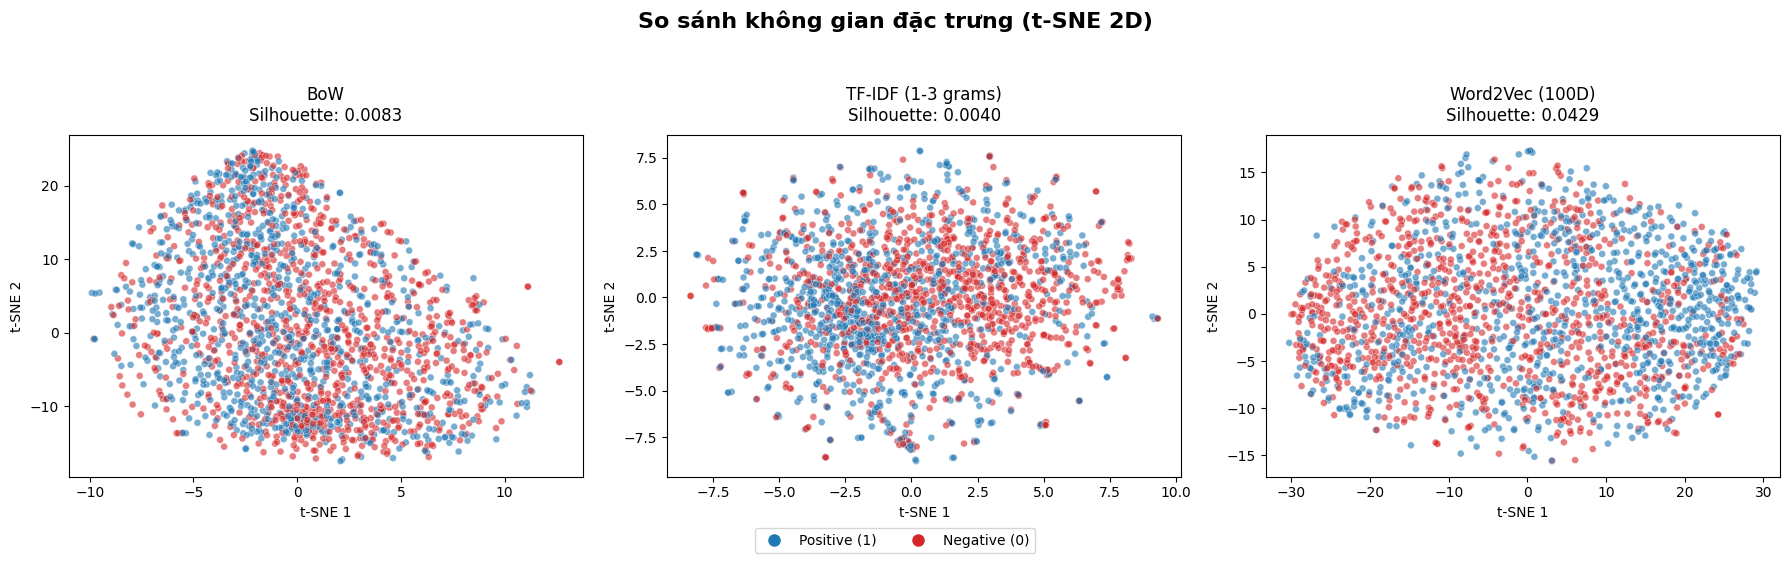


=== BẢNG TỔNG HỢP METRIC CÁC PHƯƠNG PHÁP VECTOR HÓA ===
   Phương pháp     Số chiều Độ thưa (%)  Sim tới tâm Pos  Sim tới tâm Neg  Sim giữa 2 tâm  Silhouette Score
               BoW  5,000      97.67%        0.7338           0.7337           0.9938           0.0083     
TF-IDF (1-3 grams)  5,000      96.73%        0.3771           0.3768           0.9760           0.0040     
   Word2Vec (100D)    100       0.00%        0.9261           0.9367           0.9930           0.0429     


In [ ]:
# =====================================================================
# BƯỚC 2: HÀM PHÂN TÍCH VÀ VẼ ĐỒ THỊ LÊN SUBPLOT
# =====================================================================
def analyze_representation_for_summary(X, y, method_name, ax):
    print(f"Đang xử lý: {method_name}...")
    
    # --- (i) Số chiều và Độ thưa (Sparsity) ---
    n_samples, n_features = X.shape
    if sparse.issparse(X):
        non_zeros = X.nnz
        total_elements = n_samples * n_features
    else:
        non_zeros = np.count_nonzero(X)
        total_elements = X.size
        
    sparsity = 1.0 - (non_zeros / total_elements)
    
    # --- (ii) Cosine Similarity (Centroid Approach) ---
    X_pos = X[y == 1]
    X_neg = X[y == 0]
    
    centroid_pos = np.asarray(X_pos.mean(axis=0)).reshape(1, -1)
    centroid_neg = np.asarray(X_neg.mean(axis=0)).reshape(1, -1)
    
    mean_sim_pos = cosine_similarity(X_pos, centroid_pos).mean()
    mean_sim_neg = cosine_similarity(X_neg, centroid_neg).mean()
    mean_sim_diff = cosine_similarity(centroid_pos, centroid_neg)[0][0]
    
    # --- Silhouette Score (Xấp xỉ trên 5k mẫu) ---
    # Đảm bảo sample_size không vượt quá tổng số mẫu hiện có
    s_size = min(5000, n_samples) 
    sil_score = silhouette_score(X, y, metric='cosine', sample_size=s_size, random_state=42)
    
    # --- (iii) Trực quan hóa t-SNE 2D ---
    n_tsne_samples = min(2000, n_samples)
    np.random.seed(42)
    sample_indices = np.random.choice(n_samples, n_tsne_samples, replace=False)
    X_sample = X[sample_indices]
    y_sample = y[sample_indices]
    
    tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='pca', learning_rate='auto')
    
    if sparse.issparse(X_sample):
        X_2d = tsne.fit_transform(X_sample.toarray())
    else:
        X_2d = tsne.fit_transform(X_sample)
        
    # Vẽ lên subplot (ax) được truyền vào
    sns.scatterplot(
        x=X_2d[:, 0], y=X_2d[:, 1], 
        hue=y_sample, palette={1: '#1f77b4', 0: '#d62728'}, 
        alpha=0.6, s=25, ax=ax
    )
    ax.set_title(f'{method_name}\nSilhouette: {sil_score:.4f}', fontsize=12, pad=10)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend_.remove() # Xóa legend từng hình nhỏ để gom lại sau
    
    # Trả về các chỉ số dưới dạng dictionary để tạo bảng
    return {
        "Phương pháp": method_name,
        "Số chiều": f"{n_features:,}",
        "Độ thưa (%)": f"{sparsity * 100:.2f}%",
        "Sim tới tâm Pos": round(mean_sim_pos, 4),
        "Sim tới tâm Neg": round(mean_sim_neg, 4),
        "Sim giữa 2 tâm": round(mean_sim_diff, 4),
        "Silhouette Score": round(sil_score, 4)
    }

# =====================================================================
# THỰC THI VÀ TẠO BẢNG + ĐỒ THỊ
# =====================================================================

# 1. Chuẩn bị khung hình (1 hàng, 3 cột)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
results = []

# 2. Chạy hàm cho từng phương pháp và lưu kết quả
results.append(analyze_representation_for_summary(X_bow, y, "BoW", axes[0]))
results.append(analyze_representation_for_summary(X_tfidf, y, "TF-IDF (1-3 grams)", axes[1]))
results.append(analyze_representation_for_summary(X_w2v, y, "Word2Vec (100D)", axes[2]))

# 3. Cấu hình hiển thị đồ thị tổng thể
plt.suptitle('So sánh không gian đặc trưng (t-SNE 2D)', fontsize=16, fontweight='bold', y=1.05)
import matplotlib.lines as mlines
pos_legend = mlines.Line2D([], [], color='#1f77b4', marker='o', linestyle='None', markersize=8, label='Positive (1)')
neg_legend = mlines.Line2D([], [], color='#d62728', marker='o', linestyle='None', markersize=8, label='Negative (0)')
fig.legend(handles=[pos_legend, neg_legend], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

# 4. In bảng tổng hợp bằng Pandas
print("\n=== BẢNG TỔNG HỢP METRIC CÁC PHƯƠNG PHÁP VECTOR HÓA ===")
df_results = pd.DataFrame(results)

# Căn lề hiển thị cho DataFrame đẹp hơn
pd.set_option('display.colheader_justify', 'center')
print(df_results.to_string(index=False))

**Phân tích và Đánh giá Khả năng tách lớp (Dựa trên Silhouette Score và t-SNE)**.

- Giá trị gần 1: Các điểm dữ liệu cùng lớp nằm rất sát nhau và cách xa các lớp khác (phân tách lý tưởng).

- Giá trị gần 0: Các cụm bị chồng chéo (overlapping) lên nhau rất nhiều, ranh giới không rõ ràng.

- Giá trị âm: Điểm dữ liệu bị gán sai cụm.

Nhìn vào kết quả, cả 3 phương pháp đều có Silhouette Score cực kỳ thấp (gần bằng 0). Điều này phản ánh một thực tế phổ biến trong bài toán phân tích cảm xúc (Sentiment Analysis): từ vựng của các đánh giá tích cực và tiêu cực thường chia sẻ chung một lượng lớn các từ trung tính (như "phim", "đạo diễn", "diễn viên", "cốt truyện"), dẫn đến việc không gian đặc trưng nguyên thủy bị hòa lẫn vào nhau.


1. Word2Vec (100D) - Hiệu năng tương đối tốt nhất
- **Silhouette Score**: 0.0429 (Cao nhất trong 3 phương pháp)

- **Đánh giá**: Mặc dù điểm số vẫn rất gần 0, Word2Vec cho thấy khả năng gom cụm tốt hơn hẳn BoW và TF-IDF. Nhìn vào biểu đồ t-SNE, có thể thấy dù các chấm xanh (Positive) và đỏ (Negative) vẫn trộn lẫn, nhưng nó đã tạo thành một khối đặc và có xu hướng hình thành các vùng tập trung nhẹ.

- **Nguyên nhân**: Word2Vec nén dữ liệu từ không gian hàng ngàn chiều xuống chỉ còn 100 chiều (Sparsity 0.00% - ma trận hoàn toàn đặc). Phương pháp này (Mean Pooling) lấy trung bình các véc-tơ ngữ nghĩa, giúp làm mờ đi nhiễu từ các từ hiếm và giữ lại "ý chính" của câu. Các điểm dữ liệu cũng có độ tương đồng với tâm cụm của chính nó rất cao (Sim tới tâm Pos/Neg ~ 0.93).

2. Bag of Words (BoW)
- **Silhouette Score**: 0.0083

- **Đánh giá**: Khả năng tách lớp hầu như không có. T-SNE cho thấy các điểm phân bố thành một đám mây lớn đan xen hoàn toàn vào nhau.

- **Nguyên nhân**: BoW tạo ra không gian cực kỳ thưa thớt (Sparsity 97.67%). Trong không gian 5000 chiều này, hầu hết các giá trị là 0. Đặc biệt, chỉ số "Sim giữa 2 tâm" lên tới 0.9938, nghĩa là tâm của cụm Positive và tâm của cụm Negative gần như trùng khít lên nhau trong không gian véc-tơ. Do đó, thuật toán không thể tìm ra ranh giới rõ ràng.

3. TF-IDF (1-3 grams) - Khả năng gom cụm kém nhất
- **Silhouette Score**: 0.0040 (Thấp nhất)

- **Đánh giá**: Biểu đồ t-SNE của TF-IDF phân tán rộng nhất và hỗn loạn nhất. Dữ liệu không hề tạo thành các cụm chặt chẽ.

- **Nguyên nhân**: Dù TF-IDF giúp giảm trọng số của các từ vô nghĩa, việc sử dụng thêm n-gram (đến 3-gram) trong khi giới hạn max_features=5000 có thể đã làm mất đi nhiều cụm từ quan trọng hoặc đưa vào quá nhiều cụm từ hiếm, làm tăng độ nhiễu. Điều này thể hiện rõ ở chỉ số "Sim tới tâm Pos/Neg" chỉ đạt khoảng 0.37 - tức là các điểm dữ liệu trong cùng một lớp nằm rất xa nhau và rời rạc, dẫn đến Silhouette Score tụt giảm nghiêm trọng.


**Kết luận chung**:
Các phương pháp vector hóa thô (raw embeddings) này tự thân nó không đủ sức để tách biệt tuyến tính hai lớp cảm xúc Positive/Negative trong không gian không có nhãn giám sát. Để giải quyết bài toán này, chúng ta buộc phải dựa vào sức mạnh của các mô hình Machine Learning có khả năng vẽ ra các siêu mặt phẳng phi tuyến (như SVM với RBF kernel, Random Forest) hoặc các mô hình Deep Learning (như LSTM, Transformer) để học các tương quan phức tạp hơn thay vì chỉ nhìn vào khoảng cách không gian đơn thuần.